In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load CSV file
train_img = pd.read_csv("sign_mnist_train.csv")
test_img = pd.read_csv("sign_mnist_test.csv")
train_img.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [4]:
train_pixels = train_img.iloc[:, 1:].values
train_label = train_img.iloc[:, :1].values
test_pixels = test_img.iloc[:, 1:].values
test_label = test_img.iloc[:, :1].values

In [5]:
train_pixels[1:10]

array([[155, 157, 156, ..., 103, 135, 149],
       [187, 188, 188, ..., 195, 194, 195],
       [211, 211, 212, ..., 222, 229, 163],
       ...,
       [114,  42,  74, ..., 227, 228, 228],
       [169, 174, 176, ...,  74,  61,  57],
       [189, 189, 189, ..., 175, 178, 156]], shape=(9, 784))

In [6]:
train_label[1:10]

array([[ 6],
       [ 2],
       [ 2],
       [13],
       [16],
       [ 8],
       [22],
       [ 3],
       [ 3]])

In [7]:
# Remapping the label value to deal with the missing J and Z labels
def remap_labels(label):
    label = label.flatten()
    unique = sorted(set(label))
    mapping = {old: new for new, old in enumerate(unique)}
    return np.array([mapping[i] for i in label])

train_label = remap_labels(train_label)
test_label = remap_labels(test_label)


In [8]:
#Normalize pixel values to [0,1]
train_pixels = train_pixels/255
test_pixels = test_pixels/255

In [9]:
train_pixels[1:10]

array([[0.60784314, 0.61568627, 0.61176471, ..., 0.40392157, 0.52941176,
        0.58431373],
       [0.73333333, 0.7372549 , 0.7372549 , ..., 0.76470588, 0.76078431,
        0.76470588],
       [0.82745098, 0.82745098, 0.83137255, ..., 0.87058824, 0.89803922,
        0.63921569],
       ...,
       [0.44705882, 0.16470588, 0.29019608, ..., 0.89019608, 0.89411765,
        0.89411765],
       [0.6627451 , 0.68235294, 0.69019608, ..., 0.29019608, 0.23921569,
        0.22352941],
       [0.74117647, 0.74117647, 0.74117647, ..., 0.68627451, 0.69803922,
        0.61176471]], shape=(9, 784))

In [10]:
# Convert to tensors
train_pixels = tf.convert_to_tensor(train_pixels, dtype=np.float32)
test_pixels = tf.convert_to_tensor(test_pixels, dtype=np.float32)
train_label = tf.convert_to_tensor(train_label, dtype=np.int32)
test_label =  tf.convert_to_tensor(test_label, dtype=np.int32)

In [11]:
type(train_pixels)

tensorflow.python.framework.ops.EagerTensor

In [12]:
train_pixels = tf.reshape(train_pixels, [-1, 28, 28, 1])
test_pixels = tf.reshape(test_pixels, [-1, 28, 28, 1])

In [13]:
train_pixels.shape

TensorShape([27455, 28, 28, 1])

In [14]:
test_label.shape

TensorShape([7172])

In [15]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_pixels, train_label))
test_set = tf.data.Dataset.from_tensor_slices((test_pixels, test_label))

In [16]:
# Create validation dataset
train_set, valid_set = tf.keras.utils.split_dataset(
    train_dataset, 
    left_size=0.8, 
    shuffle=True, 
    seed=42
)

In [17]:
# Data augmentation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
data_augment = [
    RandomRotation(0.25),
    RandomZoom(0.15)
]

In [18]:
#Batching
train_set = train_set.batch(batch_size=128, drop_remainder=False)
test_set = test_set.batch(batch_size=128, drop_remainder=False)
valid_set = valid_set.batch(batch_size=128, drop_remainder=False)

In [37]:
# Baseline model building
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation, Dropout, Input, BatchNormalization
model = Sequential([
    Input(shape=(28,28,1)),
    *data_augment,
    Conv2D(filters=32, kernel_size=(3,3)),
    Activation("relu"),
    MaxPool2D(pool_size=(2,2)),
    Flatten(),
    Dense(128),
    Activation("relu"),
    Dense(256),
    Activation("relu"),
    Dense(24),
    Activation("softmax")
])

# Training model

In [38]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [39]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │         6,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 24)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 731,864 (2.79 MB)

 Trainable params: 731,864 (2.79 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history = model.fit(x=train_set, validation_data=valid_set, epochs=15)

Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.1463 - loss: 2.8016 - val_accuracy: 0.3274 - val_loss: 2.0771
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3480 - loss: 2.0448 - val_accuracy: 0.4832 - val_loss: 1.6007
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4653 - loss: 1.6365 - val_accuracy: 0.5764 - val_loss: 1.2847
Epoch 4/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5519 - loss: 1.3557 - val_accuracy: 0.6019 - val_loss: 1.1871
Epoch 5/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6119 - loss: 1.1629 - val_accuracy: 0.6458 - val_loss: 1.0640
Epoch 6/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6581 - loss: 1.0187 - val_accuracy: 0.6578 - val_loss: 1.0378
Epoch 7/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6922 - loss: 0.9105 - val_accuracy: 0.6753 - val_loss: 0.9683
Epoch 8/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7277 - loss: 0.8149 - val_accu

# Evaluating baseline model

In [41]:
model.evaluate(test_set)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7064 - loss: 0.9354


[0.9354032278060913, 0.7063580751419067]

## Some test image true label

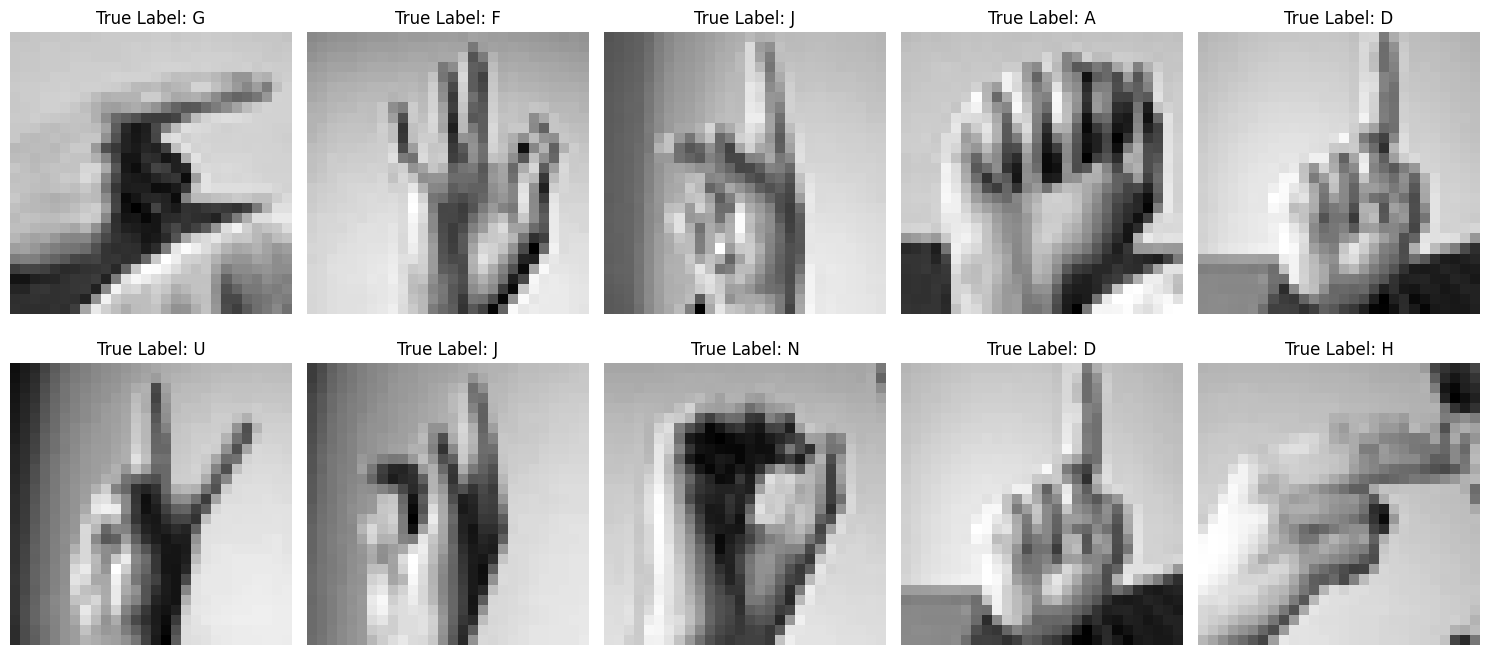

In [24]:
import string
alphabet = list(string.ascii_uppercase)

num_images = 10
fig, ax = plt.subplots(2, 5, figsize=(15, 7))
ax = ax.flatten()

for i in range(num_images):
    ax[i].imshow(test_pixels[i].numpy(), cmap='gray') 
    idx = int(test_label[i]) 
    label_char = alphabet[idx]
    
    ax[i].set_title(f"True Label: {label_char}")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

## Enhanced CNN network

In [25]:
# Based on AlexNet, adjusted for this dataset
better_net = Sequential([
    Input(shape=(28,28,1)),
    *data_augment,
    # First layer
    Conv2D(filters=96, kernel_size=(4,4), strides=(1,1), padding='same'),
    Activation('relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(3,3), strides=(2,2)),
    # Second layer
    Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding='same'),
    Activation('relu'),
    MaxPool2D(pool_size=(3,3), strides=(2,2)),
    #Third layer
    Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), padding='same'),
    Activation('relu'),
    #Forth layer
    Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), padding='same'),
    Activation('relu'),
    #Fifth layer
    Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding='same'),
    Activation('relu'),
    MaxPool2D(pool_size=(3,3), strides=(2,2)),
    Flatten(),
    # Fully connected layers
    Dense(2048),
    Activation('relu'),
    Dropout(0.5),
    Dense(1024),
    Activation('relu'),
    Dropout(0.5),
    Dense(24),
    Activation('softmax')
])

In [26]:
optim = tf.keras.optimizers.Adam(learning_rate=0.0001)

In [27]:
better_net.compile(loss="sparse_categorical_crossentropy", optimizer=optim, metrics=["accuracy"])

In [28]:
better_net.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 96)     │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 6, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │        24,60

 Total params: 7,543,032 (28.77 MB)

 Trainable params: 7,542,840 (28.77 MB)

 Non-trainable params: 192 (768.00 B)

In [29]:
history2 = better_net.fit(x=train_set, validation_data=valid_set, epochs=15)

Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 51s 284ms/step - accuracy: 0.1572 - loss: 2.7245 - val_accuracy: 0.3307 - val_loss: 2.9157
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 47s 274ms/step - accuracy: 0.4629 - loss: 1.5673 - val_accuracy: 0.6736 - val_loss: 2.0287
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 56s 328ms/step - accuracy: 0.6843 - loss: 0.8877 - val_accuracy: 0.8121 - val_loss: 0.8089
Epoch 4/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 58s 335ms/step - accuracy: 0.8111 - loss: 0.5344 - val_accuracy: 0.9306 - val_loss: 0.2512
Epoch 5/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 51s 299ms/step - accuracy: 0.8839 - loss: 0.3307 - val_accuracy: 0.9501 - val_loss: 0.1466
Epoch 6/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 48s 277ms/step - accuracy: 0.9303 - loss: 0.2006 - val_accuracy: 0.9669 - val_loss: 0.0860
Epoch 7/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 51s 297ms/step - accuracy: 0.9544 - loss: 0.1385 - val_accuracy: 0.9862 - val_loss: 0.0456
Epoch 8/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 49s 285ms/step - accuracy: 0.9694 - loss: 0

# Evaluate enhanced CNN

In [30]:
better_net.evaluate(test_set)

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9596 - loss: 0.1780


[0.1780238002538681, 0.9595649838447571]

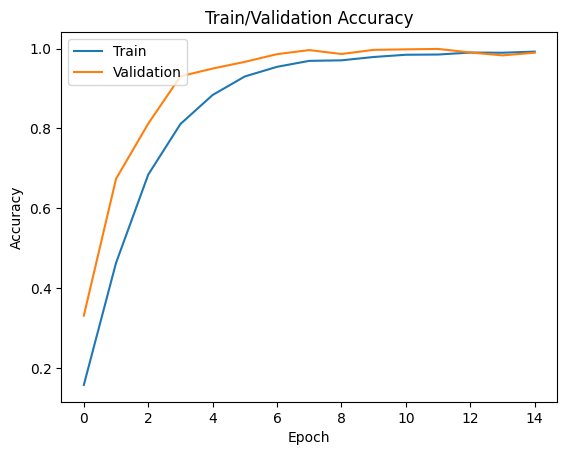

In [31]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Train/Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

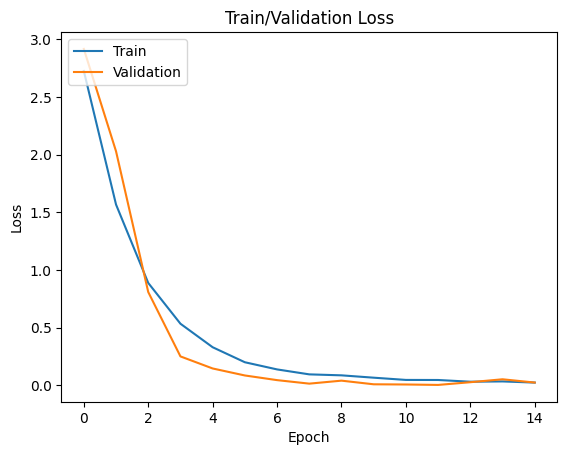

In [32]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Train/Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [33]:
# Sample predictions
prediction = better_net.predict(test_pixels)
prediction = np.argmax(prediction, axis=1)

# 10 first predictions
for i in range(0,10):
    if prediction[i] == test_label[i]:
        print("Correct")
    else:
        print("Incorrect")

225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step
Correct
Correct
Correct
Correct
Incorrect
Correct
Correct
Correct
Incorrect
Correct


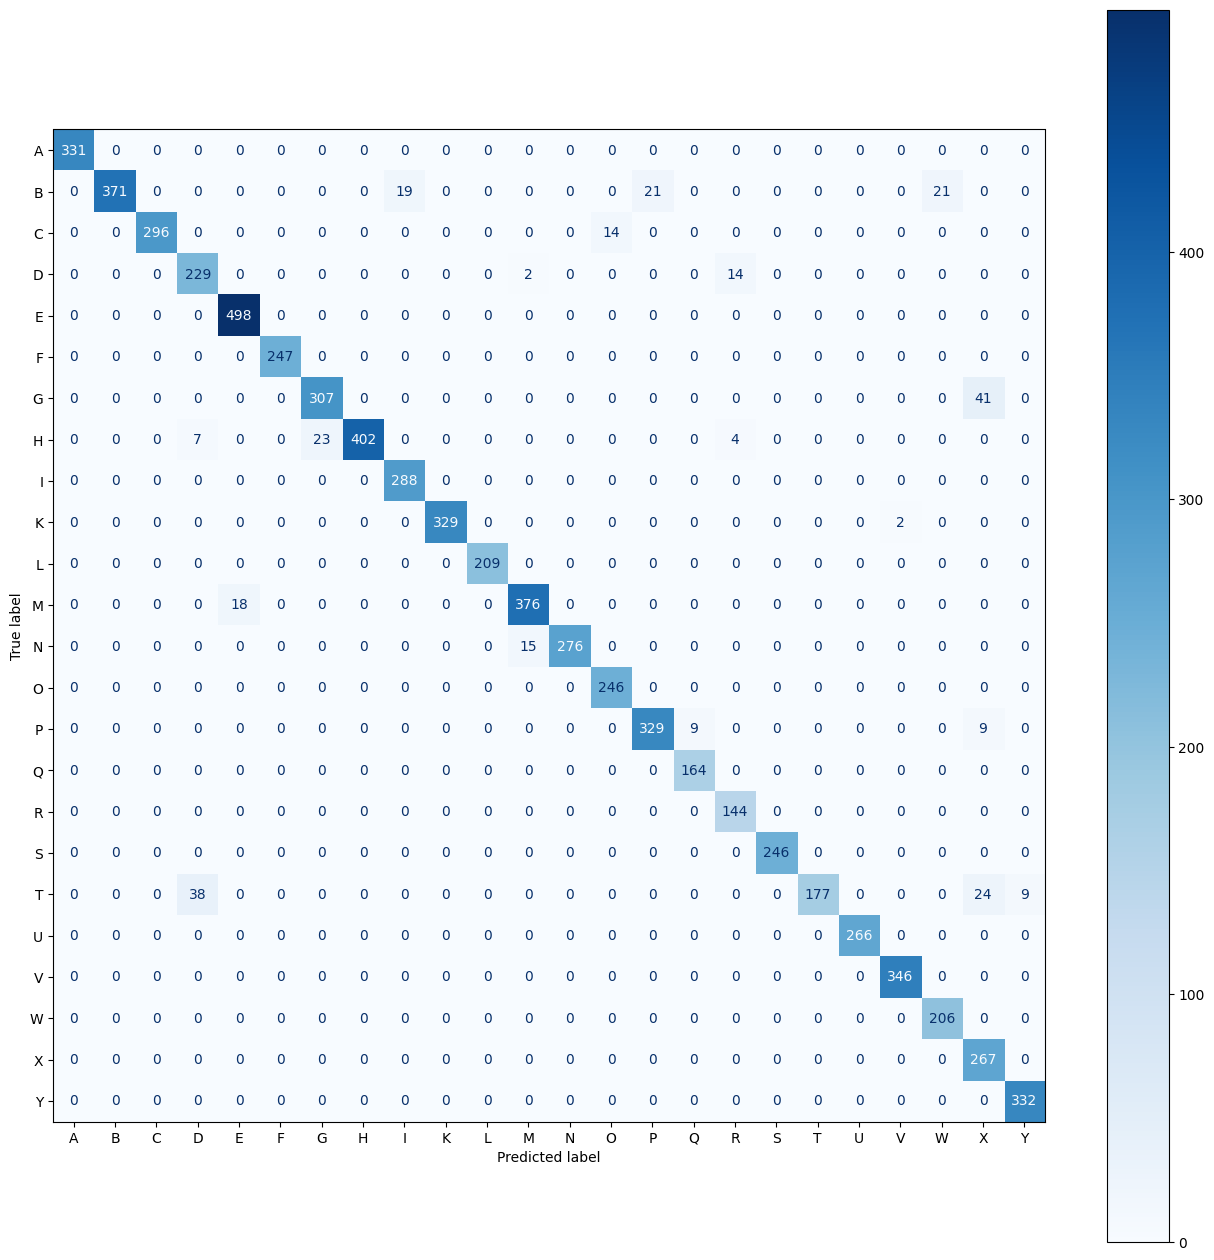

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_label, prediction)
fig, ax = plt.subplots(figsize=(16, 16)) 

labels = [char for char in string.ascii_uppercase[:25] if char != 'J']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.show()

In [36]:
from sklearn.metrics import classification_report
numpy_label = np.array(test_label).flatten()
numpy_prediction = np.array(prediction).flatten()

label = np.array(test_label)
label = np.unique(label)

report = classification_report(numpy_label, numpy_prediction, labels=label)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       1.00      0.86      0.92       432
           2       1.00      0.95      0.98       310
           3       0.84      0.93      0.88       245
           4       0.97      1.00      0.98       498
           5       1.00      1.00      1.00       247
           6       0.93      0.88      0.91       348
           7       1.00      0.92      0.96       436
           8       0.94      1.00      0.97       288
           9       1.00      0.99      1.00       331
          10       1.00      1.00      1.00       209
          11       0.96      0.95      0.96       394
          12       1.00      0.95      0.97       291
          13       0.95      1.00      0.97       246
          14       0.94      0.95      0.94       347
          15       0.95      1.00      0.97       164
          16       0.89      1.00      0.94       144
          17       1.00    